# Mini-Projeto 02 — Conselheiro Shinobi Fuzzy
**Autor:** Gabriel Rafá Martins Freire  
**Matrícula:** 20230145310  
**Modalidade:** individual • **Caminho B:** reescrever o MP1 no mesmo domínio.

Controlador **Mamdani**, implementado em **scikit-fuzzy**, para estimar a intensidade de recuo em Sekiro a partir da vida e da postura do jogador.

**Como usar:** execute todas as células na ordem. 

## 1. O que mudou em relação ao MP1?
O MP1 recomendava uma ação imediata: Mikiri, saltar, defletir, afastar, curar ou observar. Usava fatos, 14 regras Experta, três níveis de encadeamento, `salience` e `NOT` para escolher uma decisão.

O MP2 mantém o **domínio de aconselhamento de combate** e reformula o recorte: **quanto priorizar o recuo em uma janela de decisão?** A resposta agora é gradual. Não existe equivalência entre F1–F9 e as antigas R1–R14. Ataque, Mikiri, curas e abertura segura deixam de ser entradas deste controlador; postura é adicionada.

Isso atende ao Caminho B, que exige o mesmo domínio com inferência fuzzy, sem fingir que uma pontuação consegue escolher o timing de um Mikiri. A decisão numérica é calculada pelo scikit-fuzzy, não por regras nítidas escondidas em `if/else`.

## 2. Domínio, premissas e significado das variáveis
- **Vida:** porcentagem restante da vitalidade do jogador (0–100). Menor vida implica menor tolerância a erros.
- **Postura:** porcentagem **preenchida** da barra de postura **do jogador**, não a do inimigo (0–100). Maior preenchimento indica menor margem antes da quebra.
- **Recuo:** índice adimensional de 0–100 que expressa a prioridade de buscar afastamento seguro. Não representa probabilidade de sobrevivência, distância, duração nem um botão.

As entradas são estimadas manualmente pelas barras do jogo: parte preenchida dividida pela extensão total, vezes 100. Não há leitura automática de tela. O modelo considera um adversário e uma janela em que o jogador pode planejar o reposicionamento. Não trata atordoamento, morte, chefes específicos, oportunidade de golpe mortal ou timing de deflexão. Vida zero e postura 100 entram nos testes matemáticos de fronteira; vida zero não gera uma ação executável.

**Conhecimento do domínio:** a barra de postura se aproxima da quebra à medida que enche. A escolha de recuar é uma política conservadora deste projeto, e não uma regra oficial de jogo. Recuar demais também pode permitir recuperação do adversário; por isso boa vida e postura estável favorecem engajamento.

Fonte de domínio: [Activision — mecânicas de combate](https://support.activision.com/sekiro/articles/sekiro-shadows-die-twice-game-mechanics). Os limites numéricos abaixo são hipóteses de modelagem, sem calibração em partidas reais.

## 3. Instalação e importações
Versões fixadas das bibliotecas de cálculo. Ambiente validado: Python 3.12.14. No Colab, use um runtime Python padrão e execute desde a primeira célula. A primeira instalação precisa de internet. Se já importou versões diferentes, reinicie o kernel após instalar.

In [1]:
%pip install --quiet numpy==2.3.5 scipy==1.17.0 matplotlib==3.10.8 networkx==3.7 scikit-fuzzy==0.5.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
from numbers import Real
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl


%matplotlib inline
import sys, skfuzzy, scipy, matplotlib, networkx
print('Python:', sys.version.split()[0])
print('scikit-fuzzy:', skfuzzy.__version__)

No event loop hook running.
Python: 3.12.14
scikit-fuzzy: 0.5.0


## 4. Três termos por variável e suas justificativas
`trapmf[a,b,c,d]` tem suporte de a a d e pertinência 1 de b a c; `trimf[a,b,c]` tem pico em b. Termos extremos de entrada têm ombros, evitando lacunas em 0 e 100.

| Variável | Termo | Função e parâmetros | Justificativa |
|---|---|---|---|
| Vida | baixa | trapezoidal [0,0,30,60] | Mantém 30% como referência conservadora do MP1, mas deixa a pertinência cair gradualmente até 60%. |
| Vida | media | triangular [30,60,85] | Reserva intermediária: máxima em 60%, transições com baixa e alta. |
| Vida | alta | trapezoidal [60,85,100,100] | A partir de 85% considera-se boa reserva; começa a participar em 60%. |
| Postura | estavel | trapezoidal [0,0,25,50] | Pouco preenchimento oferece margem defensiva; perde força até metade da barra. |
| Postura | pressionada | triangular [25,50,75] | Metade da barra representa uma condição intermediária. |
| Postura | critica | trapezoidal [50,75,100,100] | A partir de três quartos da barra, a política é conservadora com a margem restante. |
| Recuo | baixo | triangular [0,20,40] | Centro 20: preferência por engajamento, sem recomendação absoluta de nunca recuar. |
| Recuo | moderado | triangular [30,50,70] | Centro 50: equilibrar engajamento e reposicionamento. |
| Recuo | alto | triangular [60,80,100] | Centro 80: prioridade de afastamento, sem prescrever retirada incondicional. |

As saídas têm mesma largura e simetria para não favorecer um termo apenas por ter mais área. Há sobreposição entre termos vizinhos. Os centros e limites são escolhas explícitas e revisáveis; não são dados oficiais nem parâmetros aprendidos. A saída observada fica entre 20 e 80 neste modelo, embora seu universo seja 0–100. Um centroide não precisa atingir as bordas do universo.

**Pertinência não é probabilidade:** vida 45% pertence a `baixa` com grau 0,5 e a `media` com grau 0,5. Isso não significa 50% de chance de estar com pouca vida.

In [3]:
# Todos os universos incluem os extremos; entradas fracionárias são interpoladas.
UNIVERSO = np.arange(0, 101, 1, dtype=float)
vida = ctrl.Antecedent(UNIVERSO, 'vida')
postura = ctrl.Antecedent(UNIVERSO, 'postura')
recuo = ctrl.Consequent(UNIVERSO, 'recuo', defuzzify_method='centroid')

# Vida remanescente (%): conserva 30 como referência do MP1, com transição gradual.
vida['baixa'] = fuzz.trapmf(UNIVERSO, [0, 0, 30, 60])
vida['media'] = fuzz.trimf(UNIVERSO, [30, 60, 85])
vida['alta'] = fuzz.trapmf(UNIVERSO, [60, 85, 100, 100])
# Postura preenchida (%): maior valor significa menor margem defensiva.
postura['estavel'] = fuzz.trapmf(UNIVERSO, [0, 0, 25, 50])
postura['pressionada'] = fuzz.trimf(UNIVERSO, [25, 50, 75])
postura['critica'] = fuzz.trapmf(UNIVERSO, [50, 75, 100, 100])
# Centros 20/50/80 evitam interpretar uma recomendação como comando absoluto.
# Triângulos simétricos de mesma largura: um único termo ativo mantém seu centro.
recuo['baixo'] = fuzz.trimf(UNIVERSO, [0, 20, 40])
recuo['moderado'] = fuzz.trimf(UNIVERSO, [30, 50, 70])
recuo['alto'] = fuzz.trimf(UNIVERSO, [60, 80, 100])

## 5. Base de conhecimento: nove regras
Todas as combinações dos três termos de vida com os três de postura estão contempladas.

| Vida / postura | Estável | Pressionada | Crítica |
|---|---|---|---|
| Baixa | F1: moderado | F2: alto | F3: alto |
| Média | F4: baixo | F5: moderado | F6: alto |
| Alta | F7: baixo | F8: baixo | F9: moderado |

Por exemplo: **F2 — SE vida é baixa E postura é pressionada, ENTÃO recuo é alto.**

Vida baixa com postura estável permite um reposicionamento moderado; juntando pouca vida e pressão de postura, favorecemos recuo alto. Com vida alta, o controlador tolera mais pressão, mas postura crítica ainda recomenda cautela moderada. A tabela é ordenada linguisticamente: maior postura não reduz o termo de recuo; maior vida não o aumenta. Isso, sozinho, não constitui prova de monotonicidade numérica global do centroide.

Não há uma “regra vencedora”. Todas as regras com grau positivo contribuem. Repetir três regras com consequente `alto` não triplica sua força: a agregação usa máximo.

In [4]:
# Cada linha é uma regra fuzzy SE vida E postura ENTÃO recuo.
# As nove combinações (3 x 3) são explícitas e cobrem as entradas por completo.
BASE = [
    ('F1', 'baixa', 'estavel', 'moderado'),
    ('F2', 'baixa', 'pressionada', 'alto'),
    ('F3', 'baixa', 'critica', 'alto'),
    ('F4', 'media', 'estavel', 'baixo'),
    ('F5', 'media', 'pressionada', 'moderado'),
    ('F6', 'media', 'critica', 'alto'),
    ('F7', 'alta', 'estavel', 'baixo'),
    ('F8', 'alta', 'pressionada', 'baixo'),
    ('F9', 'alta', 'critica', 'moderado'),
]
regras = [ctrl.Rule(vida[v] & postura[p], recuo[r], label=rotulo)
          for rotulo, v, p, r in BASE]
sistema = ctrl.ControlSystem(regras)
# AND = mínimo; implicação = corte pelo mínimo; acumulação = máximo;
# defuzzificação = centroide. Nenhuma regra tem prioridade ou peso especial.

## 6. Pipeline Mamdani e explicação da saída
1. **Fuzzificação:** converter os números em graus de pertinência.
2. **Antecedentes:** para cada regra, calcular α = mínimo dos graus da vida e da postura (operador E).
3. **Implicação:** cortar a função de pertinência da saída na altura α.
4. **Agregação:** tomar o máximo dos consequentes cortados.
5. **Defuzzificação:** calcular o centroide da área agregada.

$$\mu_{agregada}(z)=\max_i\min(\alpha_i,\mu_{consequente_i}(z))$$
$$z^*=\frac{\int z\,\mu_{agregada}(z)\,dz}{\int\mu_{agregada}(z)\,dz}$$

A biblioteca executa o controlador com `ControlSystemSimulation.compute()`. O código lê `aggregate_firing` de cada regra para mostrar seu grau efetivo. Não há `salience`, agenda de vencedoras ou guarda `NOT`.

`interpretar()` só produz um resumo depois do cálculo: abaixo de 35, baixo; de 35 a 65, moderado; acima de 65, alto. Esses cortes são os pontos médios entre os centros 20, 50 e 80. O número contínuo permanece disponível e não é substituído pelo rótulo. O arredondamento interno desse resumo evita ruído de ponto flutuante nos limites.

In [5]:
def validar_percentual(nome, valor):
    """Recusa dados inválidos antes do scikit-fuzzy (sem recorte silencioso)."""
    if isinstance(valor, (bool, np.bool_)) or not isinstance(valor, Real):
        raise ValueError(f'{nome}: informe um número real, sem booleanos.')
    if not np.isfinite(valor) or not 0 <= valor <= 100:
        raise ValueError(f'{nome}: valor finito entre 0 e 100, inclusive.')
    return float(valor)


def interpretar(valor):
    """Resumo textual posterior à inferência, sem mudar a saída numérica."""
    valor = round(float(valor), 8)  # Evita que ruído de ponto flutuante altere rótulos nos limites.
    if valor < 35:
        return 'Recuo baixo: manter o engajamento, observando o próximo golpe.'
    if valor <= 65:
        return 'Recuo moderado: reduzir a exposição e buscar reposicionamento seguro.'
    return 'Recuo alto: priorizar uma oportunidade segura de afastamento.'


def avaliar(vida_pct, postura_pct, explicar=True):
    v = validar_percentual('vida', vida_pct)
    p = validar_percentual('postura', postura_pct)
    sim = ctrl.ControlSystemSimulation(sistema, clip_to_bounds=False)
    sim.input['vida'], sim.input['postura'] = v, p
    sim.compute()  # A decisão é calculada realmente pelo scikit-fuzzy.
    saida = float(sim.output['recuo'])
    pertinencias = {
        var.label: {nome: float(fuzz.interp_membership(var.universe, termo.mf, x))
                    for nome, termo in var.terms.items()}
        for var, x in [(vida, v), (postura, p)]
    }
    # Os graus são lidos da execução do motor, não de um seletor paralelo.
    ativacoes = [dict(regra=r.label, grau=float(r.aggregate_firing[sim]),
                      consequente=linha[3]) for r, linha in zip(regras, BASE)]
    resultado = dict(vida=v, postura=p, recuo=saida,
                     interpretacao=interpretar(saida),
                     pertinencias=pertinencias, ativacoes=ativacoes)
    if explicar:
        print(f'Vida: {v:g}% | Postura preenchida: {p:g}%')
        for nome, valores in pertinencias.items():
            print(nome + ': ' + ', '.join(f'{k}={g:.3f}' for k, g in valores.items()))
        for item in ativacoes:
            if item['grau'] > 0:
                print(f"{item['regra']}: α={item['grau']:.3f} → recuo {item['consequente']}")
        print(f'Centroide: {saida:.4f}/100. {resultado["interpretacao"]}')
        if v == 0:
            print('Vida zero: apenas teste matemático de fronteira; sem ação para jogador morto.')
    return resultado

## 7. Gráficos das funções de pertinência
A função abaixo também prepara o gráfico de agregação e a superfície de controle. O gráfico de inferência explica os cortes; a saída principal continua sendo calculada pelo motor scikit-fuzzy.

In [6]:
def grafico_pertinencias():
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), constrained_layout=True)
    for ax, var, titulo in zip(axes, [vida, postura, recuo],
                               ['Vida restante (%)', 'Postura preenchida (%)', 'Índice de recuo']):
        for nome, termo in var.terms.items():
            ax.plot(var.universe, termo.mf, label=nome, linewidth=2)
        ax.set(xlim=(0, 100), ylim=(-0.03, 1.12), xlabel=titulo, ylabel='Pertinência μ')
        ax.legend(fontsize=9)
        ax.grid(alpha=.2)
    fig.suptitle('Conselheiro Shinobi • conjuntos fuzzy', fontsize=14)
    return fig


def grafico_inferencia(resultado):
    """Reconstitui os cortes para explicar o motor; não substitui sim.compute()."""
    # Adiciona pontos de interseção de cada corte e da envoltória para centroide exato.
    cortes = {nome: max([a['grau'] for a in resultado['ativacoes']
                       if a['consequente'] == nome], default=0) for nome in recuo.terms}
    xs = list(UNIVERSO)
    for nome, altura in cortes.items():
        mf = recuo[nome].mf
        for i in range(len(UNIVERSO)-1):
            a, b = mf[i], mf[i+1]
            if min(a, b) < altura < max(a, b):
                xs.append(UNIVERSO[i] + (altura-a)/(b-a))
    x = np.unique(xs)
    curvas = {n: np.minimum(h, fuzz.interp_membership(UNIVERSO, recuo[n].mf, x))
              for n, h in cortes.items()}
    # Cruzamentos entre as curvas cortadas também pertencem à envoltória máximo.
    extras = []
    nomes = list(curvas)
    for i, a in enumerate(nomes):
        for b in nomes[i+1:]:
            dif = curvas[a] - curvas[b]
            for j in np.where(dif[:-1] * dif[1:] < 0)[0]:
                extras.append(x[j] - dif[j] * (x[j+1]-x[j])/(dif[j+1]-dif[j]))
    x = np.unique(np.r_[x, extras])
    curvas = {n: np.minimum(h, fuzz.interp_membership(UNIVERSO, recuo[n].mf, x))
              for n, h in cortes.items()}
    agregado = np.maximum.reduce(list(curvas.values()))
    fig, ax = plt.subplots(figsize=(9, 3.8), constrained_layout=True)
    for nome, y in curvas.items():
        ax.plot(x, y, label=f'{nome} (corte {cortes[nome]:.3f})', linewidth=2)
    ax.fill_between(x, agregado, color='#4d95a6', alpha=.2, label='União dos consequentes')
    ax.axvline(resultado['recuo'], color='#b75326', linestyle='--',
               label=f"Centroide = {resultado['recuo']:.2f}")
    ax.set(xlabel='Índice de recuo', ylabel='Pertinência μ', xlim=(0, 100), ylim=(0, 1.12),
           title=f"Mamdani: vida {resultado['vida']:g}% · postura {resultado['postura']:g}%")
    ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(alpha=.2)
    return fig


def superficie(n=21):
    """Consulta efetivamente o ControlSystemSimulation em uma grade n x n."""
    eixo = np.linspace(0, 100, n)
    z = np.empty((n, n))
    sim = ctrl.ControlSystemSimulation(sistema, clip_to_bounds=False, flush_after_run=n*n+1)
    for i, v in enumerate(eixo):
        for j, p in enumerate(eixo):
            sim.input['vida'], sim.input['postura'] = float(v), float(p)
            sim.compute()
            z[i, j] = sim.output['recuo']
    return eixo, z


def grafico_superficie(eixo, z):
    fig, ax = plt.subplots(figsize=(7.6, 5), constrained_layout=True)
    mapa = ax.pcolormesh(eixo, eixo, z, shading='auto', cmap='YlOrRd', vmin=0, vmax=100)
    fig.colorbar(mapa, ax=ax, label='Índice de recuo')
    ax.set(xlabel='Postura preenchida (%)', ylabel='Vida restante (%)',
           title='Superfície de controle • consultas ao scikit-fuzzy')
    return fig

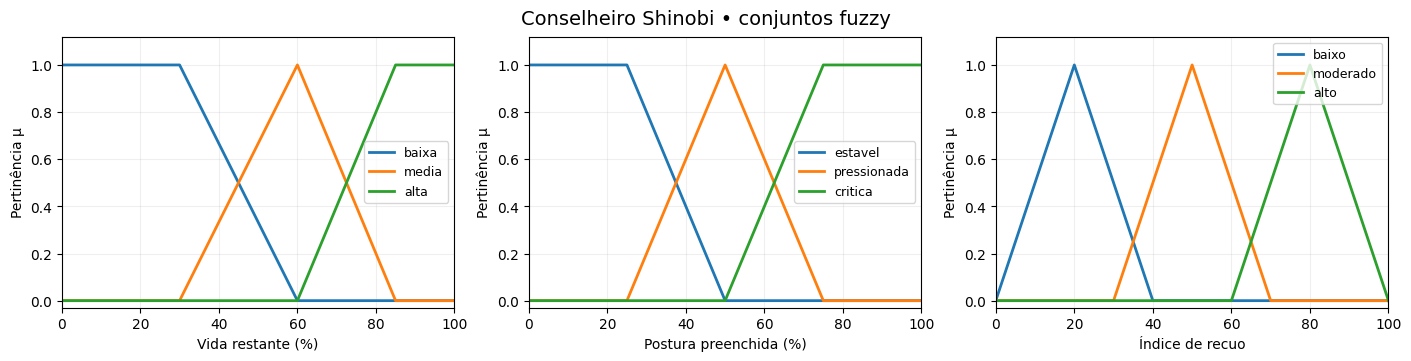

In [7]:
grafico_pertinencias()
plt.show()

## 8. Três casos de teste comentados
As saídas esperadas foram definidas antes das verificações: os dois primeiros casos ativam um único termo simétrico; o terceiro combina áreas simétricas em torno de 65. Cada teste tem entradas, saída defuzzificada e interpretação comentadas no código.

In [8]:
def testes_principais():
    # C1: vida 20%, postura 90% → 80.0000. Só F3 (grau 1).
    # Pouca vida e pouca margem de postura: priorizar afastamento seguro.
    c1 = avaliar(20, 90)
    assert np.isclose(c1['recuo'], 80, atol=1e-6)
    assert [a['regra'] for a in c1['ativacoes'] if a['grau'] > 0] == ['F3']

    # C2: vida 90%, postura 10% → 20.0000. Só F7 (grau 1).
    # Boa reserva de vida e postura estável: baixa necessidade de recuo.
    c2 = avaliar(90, 10)
    assert np.isclose(c2['recuo'], 20, atol=1e-6)

    # C3: vida 45%, postura 62.5% → 65.0000. F2, F3, F5, F6: 0.5 cada.
    # Vida é baixa E média em grau 0.5; postura é pressionada E crítica em 0.5.
    # Consequentes: moderado cortado em 0.5 e alto cortado em 0.5.
    # As áreas têm o mesmo tamanho e são simétricas em torno de 65.
    # Não há uma regra vencedora: a combinação explica o resultado intermediário.
    c3 = avaliar(45, 62.5)
    assert np.isclose(c3['recuo'], 65, atol=1e-6)
    assert 'moderado' in c3['interpretacao']
    assert [a['regra'] for a in c3['ativacoes'] if a['grau'] > 0] == ['F2', 'F3', 'F5', 'F6']
    assert all(np.isclose(a['grau'], .5) for a in c3['ativacoes'] if a['grau'] > 0)
    print('3 CASOS PRINCIPAIS: APROVADOS')
    return [c1, c2, c3]


casos = testes_principais()

Vida: 20% | Postura preenchida: 90%
vida: baixa=1.000, media=0.000, alta=0.000
postura: estavel=0.000, pressionada=0.000, critica=1.000
F3: α=1.000 → recuo alto
Centroide: 80.0000/100. Recuo alto: priorizar uma oportunidade segura de afastamento.
Vida: 90% | Postura preenchida: 10%
vida: baixa=0.000, media=0.000, alta=1.000
postura: estavel=1.000, pressionada=0.000, critica=0.000
F7: α=1.000 → recuo baixo
Centroide: 20.0000/100. Recuo baixo: manter o engajamento, observando o próximo golpe.
Vida: 45% | Postura preenchida: 62.5%
vida: baixa=0.500, media=0.500, alta=0.000
postura: estavel=0.000, pressionada=0.500, critica=0.500
F2: α=0.500 → recuo alto
F3: α=0.500 → recuo alto
F5: α=0.500 → recuo moderado
F6: α=0.500 → recuo alto
Centroide: 65.0000/100. Recuo moderado: reduzir a exposição e buscar reposicionamento seguro.
3 CASOS PRINCIPAIS: APROVADOS


## 9. Passo a passo do caso misto: vida 45, postura 62,5
1. Vida: baixa = (60−45)/30 = **0,5**; média = (45−30)/30 = **0,5**; alta = 0.
2. Postura: estável = 0; pressionada = (75−62,5)/25 = **0,5**; crítica = (62,5−50)/25 = **0,5**.
3. F2, F3, F5 e F6 têm α = min(0,5;0,5) = **0,5**. As outras têm grau zero.
4. F2, F3 e F6 apontam para `alto`; o máximo de 0,5, 0,5 e 0,5 é **0,5**. F5 aponta para `moderado` com **0,5**.
5. Os triângulos moderado e alto são cortados nessa altura. A união é simétrica em torno de **65**; seu centroide é **65/100**.

Não se conta o número de regras por consequência. Não há uma escolha por prioridade como a antiga disputa R12 × R14. Este caso demonstra raciocínio gradual, e não apenas testes nos centros dos termos.

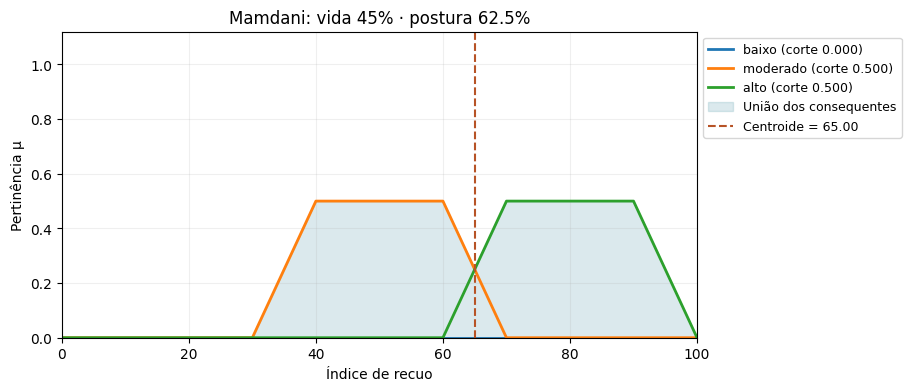

In [9]:
grafico_inferencia(casos[2])
plt.show()

## 10. Cobertura sem lacunas e testes complementares
**Argumento para todo o domínio contínuo:** em cada entrada, os termos extremos cobrem as bordas e os termos adjacentes se sobrepõem. Em qualquer ponto de [0,100], pelo menos um termo tem pertinência positiva. Como as nove combinações constam na base, para qualquer par de entradas existe uma regra com mínimo positivo. Seu consequente tem área positiva; portanto a união também tem área positiva e permite defuzzificação. Isso prova cobertura, não eficácia em partidas.

O teste na grade é uma verificação adicional da implementação, não uma prova de todos os reais: 441 pares, nove regras isoladas, quatro extremos, 16 entradas inválidas e uma verificação ao redor do limiar antigo de 30%. Também verificamos as partições em 10.001 amostras por entrada.

In [10]:
def testes_complementares(n=21):
    # Prova numérica adicional: partições em malha fina, incluindo extremos e decimais.
    fino = np.linspace(0, 100, 10001)
    for var in [vida, postura]:
        soma = sum(fuzz.interp_membership(UNIVERSO, t.mf, fino) for t in var.terms.values())
        assert np.all(soma > 0), f'Lacuna em {var.label}'
        assert np.allclose(soma, 1), f'Partição inesperada em {var.label}'
    assert len({(v, p) for _, v, p, _ in BASE}) == 9
    # Testa as nove regras isoladamente nos centros dos antecedentes.
    centros_v = {'baixa': 20, 'media': 60, 'alta': 90}
    centros_p = {'estavel': 10, 'pressionada': 50, 'critica': 90}
    centros_r = {'baixo': 20, 'moderado': 50, 'alto': 80}
    for rotulo, v, p, r in BASE:
        saida = avaliar(centros_v[v], centros_p[p], explicar=False)
        assert np.isclose(saida['recuo'], centros_r[r], atol=1e-6)
        assert [a['regra'] for a in saida['ativacoes'] if a['grau'] > 0] == [rotulo]
    # Valida entradas em ambas as posições, sem converter True em 1 ou texto em número.
    invalidos = [-1, 101, np.nan, np.inf, -np.inf, True, '50', None]
    for ruim in invalidos:
        for v, p in [(ruim, 50), (50, ruim)]:
            try:
                avaliar(v, p, explicar=False)
            except ValueError:
                pass
            else:
                raise AssertionError(f'Entrada inválida aceita: {v}, {p}')
    # Extremos de todo o domínio matemático.
    for v, p, esperado in [(0, 0, 50), (0, 100, 80), (100, 0, 20), (100, 100, 50)]:
        assert np.isclose(avaliar(v, p, False)['recuo'], esperado)
    # A transição não produz salto na vizinhança do antigo limiar nítido de 30%.
    antes = avaliar(29.9, 50, False)['recuo']
    depois = avaliar(30.1, 50, False)['recuo']
    assert abs(antes - depois) < 1
    eixo, z = superficie(n)
    assert np.isfinite(z).all() and (z >= 0).all() and (z <= 100).all()
    print(f'APROVADO: 9 regras isoladas; 16 entradas inválidas; 4 extremos; '
          f'transição 29.9→30.1; {n*n} consultas de cobertura.')
    print(f'Faixa observada: {z.min():.4f} a {z.max():.4f}. '
          f'Perto de 30%: {antes:.4f} → {depois:.4f}.')
    return eixo, z


eixo, z = testes_complementares()

APROVADO: 9 regras isoladas; 16 entradas inválidas; 4 extremos; transição 29.9→30.1; 441 consultas de cobertura.
Faixa observada: 20.0000 a 80.0000. Perto de 30%: 80.0000 → 79.8245.


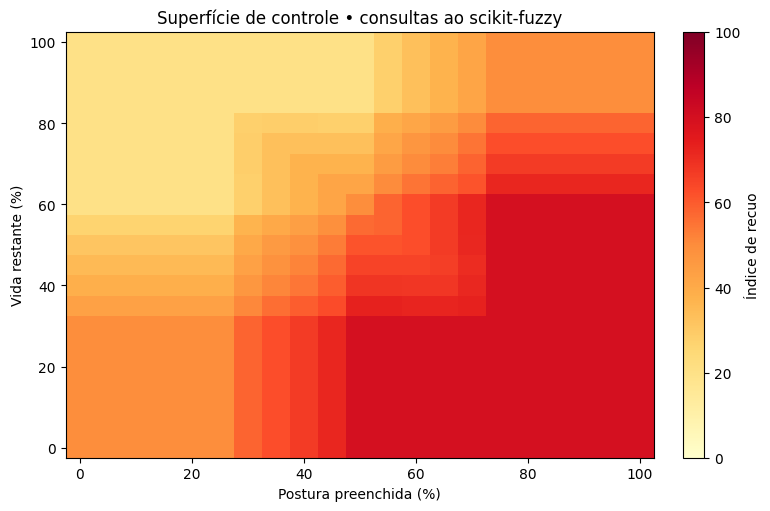

In [11]:
grafico_superficie(eixo, z)
plt.show()

## 11. Comparação crítica com o MP1
| Aspecto | MP1: Experta | MP2: Mamdani |
|---|---|---|
| Pergunta | Qual ação imediata recomendar? | Quanto priorizar recuo? |
| Conhecimento | 14 regras nítidas, fatos e três níveis | Nove regras fuzzy e nove conjuntos de pertinência |
| Verdade | Condições booleanas, como vida ≤30 | Graus entre 0 e 1, como vida baixa em 0,5 |
| Combinação | Prioridade `salience` e `NOT` para decisão única | Mínimo, máximo e centroide; múltiplas contribuições |
| Explicação | Trace e cadeia causal da vencedora | Pertinências, graus, cortes, área e centroide |
| Expressividade | Bom para condições categóricas: ataque, habilidade, cura | Bom para grandezas graduais: vida, postura, intensidade |
| Complexidade de modelagem | Encadeamento e política de conflitos | Escolher funções, sobreposições e validar superfície |
| Crescimento | Novos fatos e interações podem aumentar o encadeamento | Base completa com k entradas e 3 termos pode crescer como 3^k |
| Limitação | Fronteiras abruptas e poucas medidas contínuas | Calibração subjetiva; índice não escolhe reação específica |

Comparar “14 contra 9 regras” **não prova** que fuzzy seja mais simples: o recorte mudou. Não medimos desempenho computacional comparativo. As duas abordagens representam conhecimento explícito, sem treinamento de rede neural.

No MP1, R1 deixa de concluir vida baixa acima de 30%. Aqui, vida 30,1 ainda é baixa com pertinência próxima de 1. A consulta complementar mostra a mudança gradual da saída ao redor desse limite.

## 12. Experimente seu cenário
Altere os dois números abaixo. A postura que faltava no seu exemplo antigo precisa ser informada; não é correto inferi-la apenas pelo ataque “agarrão”. Este modelo não usa `mikiri`, `curas` ou `abertura_segura`.

Vida: 30% | Postura preenchida: 80%
vida: baixa=1.000, media=0.000, alta=0.000
postura: estavel=0.000, pressionada=0.000, critica=1.000
F3: α=1.000 → recuo alto
Centroide: 80.0000/100. Recuo alto: priorizar uma oportunidade segura de afastamento.


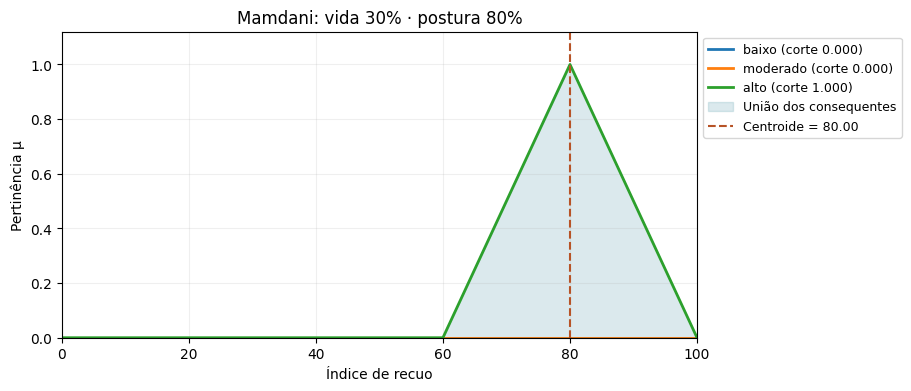

In [12]:
minha_vida = 30
minha_postura = 80  # Novo dado informado manualmente, não inferido do agarrão.
meu_resultado = avaliar(minha_vida, minha_postura)
grafico_inferencia(meu_resultado)
plt.show()